# Week 9: AI Interpretation Tools

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'], inplace=True)
df_features = df.iloc[:, :-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index = X.index)

X_scaled

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682
...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161


## Partial Least Square Discriminant Analysis (PLS-DA)

In [4]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=2)

pls.fit(X_train, y_train)

y_pred_continuous = pls.predict(X_test)

# Convert to binary (PLS-DA step)
y_pred = (y_pred_continuous >= 0.5).astype(int).ravel()

In [5]:
y_pred_continuous

array([ 0.17156872,  0.43958191,  0.82144336,  0.11113637,  0.12581711,
        0.22665806,  0.23544773,  0.37400232,  0.16119023,  0.21338601,
        0.16326556,  0.14679578,  0.43090506,  0.53646553,  0.39777653,
        0.44120985,  0.27175133,  0.08746168,  0.67928171,  0.57792189,
       -0.00714713,  0.48435109,  0.33321914,  0.3718719 , -0.12091315,
        0.68116014,  0.11375743,  0.32688454,  0.02098802,  0.2270986 ,
        0.3757045 ,  0.26732806,  0.35782834,  0.47995919, -0.09013448,
        0.09216614,  0.57871723,  0.12606581,  0.16198113,  0.47378546,
        0.55135139,  0.49040746,  0.01500348,  0.02434423,  0.22515326,
        0.43014402,  0.50129661,  0.26192169,  0.97725323,  0.51752218,
        0.6473837 ,  0.12527809,  0.15397366,  0.21826397,  0.2460713 ,
        0.31944032,  0.14615841,  0.61086665,  0.04215369,  0.49073303,
        0.41710827,  0.07803535,  0.26039594,  0.07547391,  0.55550617,
        0.30476854,  0.49031584,  0.21607557,  0.43040228,  0.35

In [6]:
y_pred 

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0])

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.7222222222222222
Precision: 0.625
Recall: 0.7222222222222222
F1-score: 0.4444444444444444


### Interpretation Step on PLS-DA

In [8]:
# Fit PLS-DA onl full dataset
pls = PLSRegression(n_components=2)
pls.fit(X_scaled, y)

scores = pls.x_scores_
loadings = pls.x_loadings_

scores_df = pd.DataFrame(scores, columns=['LV1', 'LV2'])
loadings_df = pd.DataFrame(loadings, index=X_scaled.columns, columns=['LV1', 'LV2'])

loadings_df

,LV1,LV2
age,0.465249,0.031645
anaemia,0.126058,-0.023490
creatinine_phosphokinase,0.026978,0.511688
diabetes,-0.041449,0.253259
ejection_fraction,-0.446911,-0.273415
high_blood_pressure,0.129550,0.194508
platelets,-0.158454,0.423066
serum_creatinine,0.580596,-0.102095
serum_sodium,-0.464260,0.415165
sex,0.077840,-0.468866


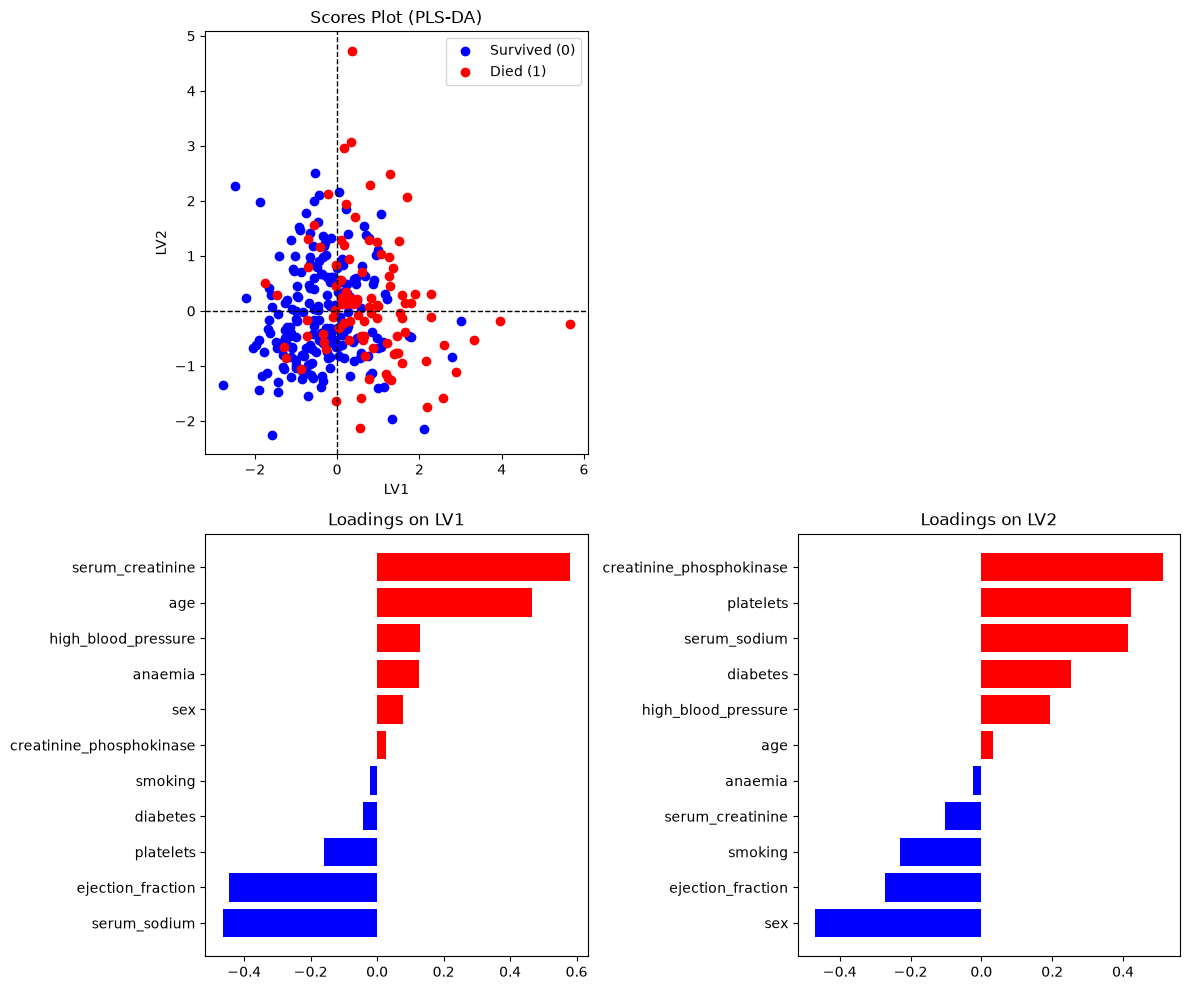

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- (1, 1) Scores Plot ---
ax = axes[0, 0]

# Plot each class separately for legend
mask_0 = (y == 0)
mask_1 = (y == 1)

ax.scatter(
    scores_df.loc[mask_0, 'LV1'],
    scores_df.loc[mask_0, 'LV2'],
    color='blue', label='Survived (0)'
)
ax.scatter(
    scores_df.loc[mask_1, 'LV1'],
    scores_df.loc[mask_1, 'LV2'],
    color='red', label='Died (1)'
)

ax.axhline(0, linestyle='--', linewidth=1, color='black')
ax.axvline(0, linestyle='--', linewidth=1, color='black')

ax.set_title('Scores Plot (PLS-DA)')
ax.set_xlabel('LV1')
ax.set_ylabel('LV2')
ax.legend()

# --- (2, 1) Loadings LV1 ---
ax = axes[1, 0]
lv1_sorted = loadings_df['LV1'].sort_values()
colors_lv1 = ['blue' if val < 0 else 'red' for val in lv1_sorted]

ax.barh(lv1_sorted.index, lv1_sorted.values, color=colors_lv1)
ax.set_title('Loadings on LV1')

# --- (2, 2) Loadings LV2 ---
ax = axes[1, 1]
lv2_sorted = loadings_df['LV2'].sort_values()
colors_lv2 = ['blue' if val < 0 else 'red' for val in lv2_sorted]

ax.barh(lv2_sorted.index, lv2_sorted.values, color=colors_lv2)
ax.set_title('Loadings on LV2')

# --- (1, 2) Empty ---
axes[0, 1].axis('off')

plt.tight_layout()
plt.show()

## SHAP

First step is to design a classifier and use SHAP to explain this classification for you

### Global interpretation: Summary (Beeswarm) plot 

Background dataset has 299 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=299 when initializing the masker.


(299, 11, 2)


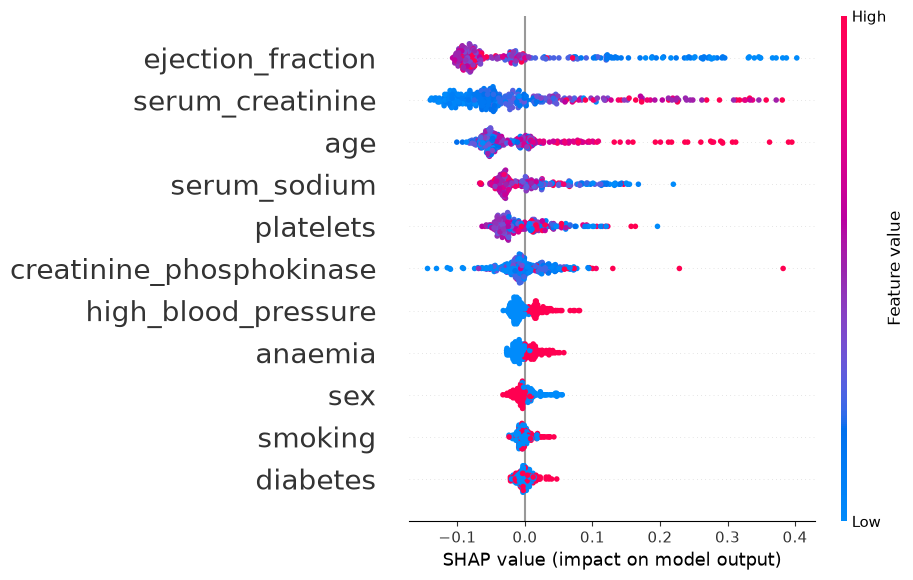

In [10]:
from sklearn.ensemble import RandomForestClassifier
import shap

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_scaled, y)

explainer = shap.Explainer(rf, X_scaled)
shap_values = explainer(X_scaled)
print(shap_values.shape)

fig = shap.summary_plot(shap_values[:, :, 1], X_scaled, show=False)
plt.gca().tick_params(axis='y', labelsize=20)
plt.show()

### Local interpretation on a single sample using SHAP waterfall plot

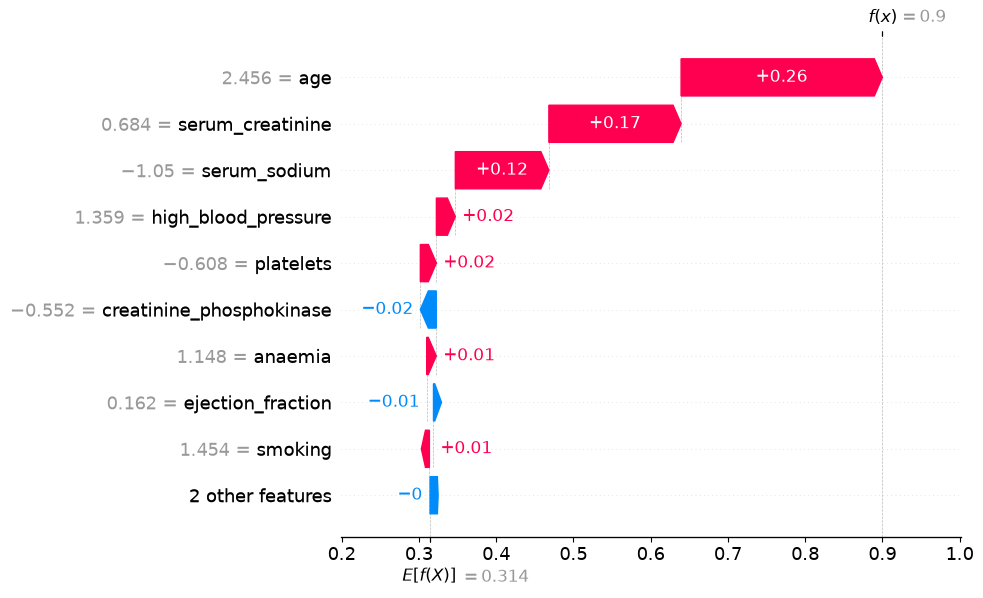

In [11]:
idx = 5
shap.plots.waterfall(shap_values[5, :, 1])

### Use SHAP on a deep learning (simple MLP) model

A simple MLP model with 1 hidden layer, 10 neurons, ReLU activation, Binary Cross Entropy loss, Adam optimizer, and 200 epochs

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

X_tensor = torch.tensor(X_scaled.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

class simpleMLP(nn.Module):
    def __init__(self, input_dim):
        super(simpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
            nn.Sigmoid() # output probability
        )

    def forward(self, x):
        return self.net(x)

model = simpleMLP(input_dim=X_tensor.shape[1])

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

def model_predict(x_numpy):
    model.eval()
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32)
    with torch.no_grad():
        preds = model(x_tensor).numpy()
    return np.hstack([1 - preds, preds])


Epoch 20, Loss: 0.5868
Epoch 40, Loss: 0.4850
Epoch 60, Loss: 0.4408
Epoch 80, Loss: 0.4041
Epoch 100, Loss: 0.3794
Epoch 120, Loss: 0.3583
Epoch 140, Loss: 0.3366
Epoch 160, Loss: 0.3155
Epoch 180, Loss: 0.2937
Epoch 200, Loss: 0.2734


In [13]:
model

simpleMLP(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

  0%|          | 0/299 [00:00<?, ?it/s]

(299, 11, 2)


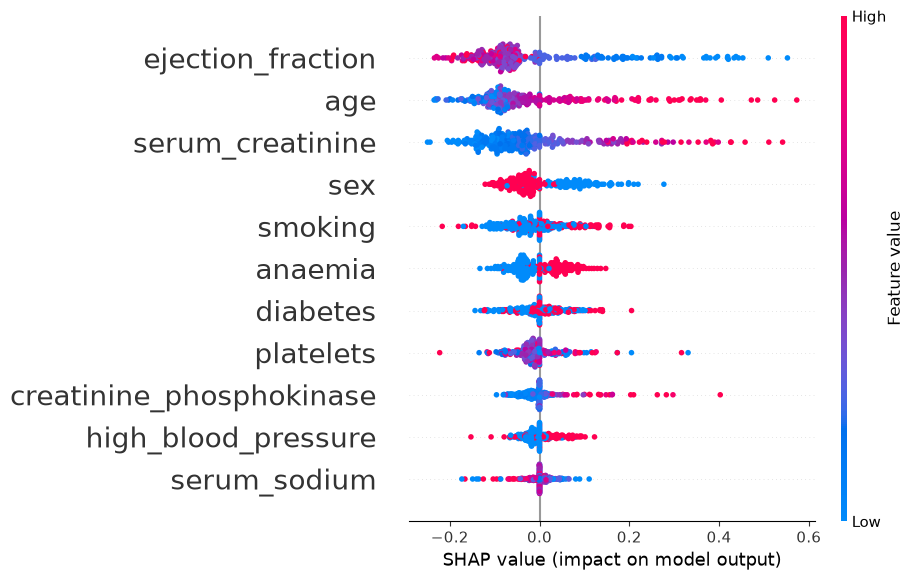

In [14]:
import shap
import numpy as np

# Background sample
background = shap.sample(X_scaled, 100, random_state=42)

explainer = shap.KernelExplainer(model_predict, background)

shap_values = explainer.shap_values(X_scaled)

print(shap_values.shape)

fig = shap.summary_plot(shap_values[:, :, 1],X_scaled,show=False)

plt.gca().tick_params(axis='y', labelsize=20)  
plt.show()